<a href="https://colab.research.google.com/github/aluminium5/Hack-O-Week-Sem-V-2026-27/blob/main/Week_7_8_Regression_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hack-o-week — Weeks 7 & 8: Regression & Classification

A supervised-learning notebook covering Linear/Polynomial/Ridge/Lasso Regression, Logistic Regression and KNN.

## Dataset
This notebook uses **Real estate valuation data set.csv**. The target variable is `Y house price of unit area`.

The dataset contains **414 rows and 8 columns**.

## Learning objectives
- Build Linear Regression.
- Capture nonlinear relationships with Polynomial Regression.
- Control model complexity using Ridge and Lasso.
- Build binary classification targets and apply Logistic Regression.
- Use KNN for classification.
- Compare regression and classification approaches.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

df = pd.read_csv("Real estate valuation data set.csv")
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

X = df[[
    "X2 house age",
    "X3 distance to the nearest MRT station",
    "X4 number of convenience stores",
    "X5 latitude",
    "X6 longitude"
]]
y = df["Y house price of unit area"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 1. Linear Regression

In [4]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

pred_linear = linear_model.predict(X_test)

print("R²:", r2_score(y_test, pred_linear))
print("RMSE:", mean_squared_error(y_test, pred_linear) ** 0.5)
print("Coefficients:", dict(zip(X.columns, linear_model.coef_)))

R²: 0.6746481382828156
RMSE: 7.387891796775484
Coefficients: {'X2 house age': np.float64(-0.2705932358164285), 'X3 distance to the nearest MRT station': np.float64(-0.0045524960137866815), 'X4 number of convenience stores': np.float64(1.105120790962548), 'X5 latitude': np.float64(236.09283090508703), 'X6 longitude': np.float64(-23.903694181762624)}


## 2. Polynomial Regression

In [5]:
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("model", LinearRegression())
])

poly_model.fit(X_train, y_train)
pred_poly = poly_model.predict(X_test)

print("Polynomial R²:", r2_score(y_test, pred_poly))
print("Polynomial RMSE:", mean_squared_error(y_test, pred_poly) ** 0.5)

Polynomial R²: 0.7510041007413613
Polynomial RMSE: 6.463086603645278


## 3. Ridge and Lasso

In [6]:
ridge_model = Pipeline([
    ("scale", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

lasso_model = Pipeline([
    ("scale", StandardScaler()),
    ("lasso", Lasso(alpha=0.1, max_iter=10000))
])

for name, model in [("Ridge", ridge_model), ("Lasso", lasso_model)]:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(name, "R² =", r2_score(y_test, pred),
          "RMSE =", mean_squared_error(y_test, pred) ** 0.5)

Ridge R² = 0.6749144123534498 RMSE = 7.3848679833021045
Lasso R² = 0.6761322962813272 RMSE = 7.371021858209651


## 4. Classification setup
Regression predicts a continuous house-price value. To demonstrate classification, we create a teaching target: whether an observation's price is above the dataset median.

In [7]:
median_price = y.median()
y_class = (y >= median_price).astype(int)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

print("Median price threshold:", median_price)
print(y_class.value_counts())

Median price threshold: 38.45
Y house price of unit area
0    207
1    207
Name: count, dtype: int64


## 5. Logistic Regression

In [8]:
logistic_model = Pipeline([
    ("scale", StandardScaler()),
    ("logistic", LogisticRegression(max_iter=2000))
])

logistic_model.fit(X_train_c, y_train_c)
pred_logistic = logistic_model.predict(X_test_c)

print("Accuracy:", accuracy_score(y_test_c, pred_logistic))

Accuracy: 0.7710843373493976


## 6. K-Nearest Neighbors (KNN)

In [9]:
knn_model = Pipeline([
    ("scale", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train_c, y_train_c)
pred_knn = knn_model.predict(X_test_c)

print("KNN accuracy:", accuracy_score(y_test_c, pred_knn))

KNN accuracy: 0.7951807228915663


## 7. Compare classification models

In [10]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN"],
    "Accuracy": [
        accuracy_score(y_test_c, pred_logistic),
        accuracy_score(y_test_c, pred_knn)
    ]
})
comparison

,Model,Accuracy
0,Logistic Regression,0.771084
1,KNN,0.795181


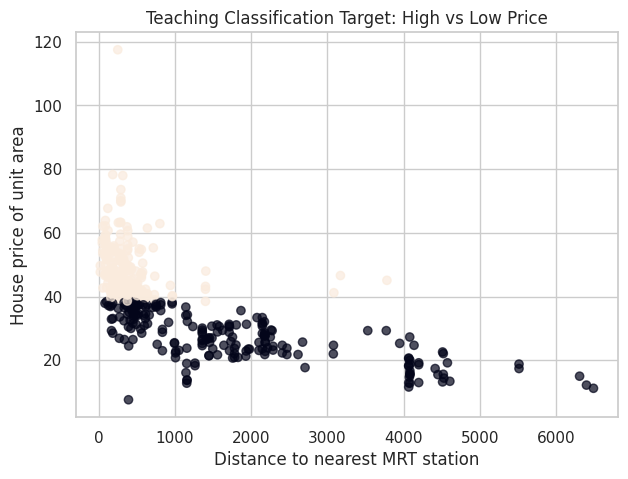

In [11]:
plt.figure(figsize=(7,5))
plt.scatter(
    df["X3 distance to the nearest MRT station"],
    df["Y house price of unit area"],
    c=y_class,
    alpha=0.7
)
plt.xlabel("Distance to nearest MRT station")
plt.ylabel("House price of unit area")
plt.title("Teaching Classification Target: High vs Low Price")
plt.show()

## Week 7–8 mini-task
1. Test polynomial degrees 1, 2 and 3.
2. Test at least three Ridge/Lasso alpha values.
3. Test KNN with `k = 3, 5, 7, 11`.
4. Record the best model and explain why scaling is important for KNN and regularized models.

## Conclusion
You have now built the main supervised-learning model families required for the next stage: regression and classification.